In [7]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten')

Loading weights: 100%|██████████| 478/478 [00:00<00:00, 6078.89it/s]
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Levenshtein Distance
The minimum number of single-character operations (insert, delete, substitute) needed to turn the predicted text into the ground truth.
### Levenshtein ratio
A measure of similarity between two strings, based on the Levenshtein distance.
### Character Error Rate (CER)

$$
CER = \frac{S + D + I}{N}
$$
### Word Error Rate (WER)

$$
WER = \frac{S + D + I}{N}
$$
### Jaccard Similarity

$$
\mathcal{J}(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$
### Jaro-Winkler Distance
It is a variant of the Jaro similarity that adds a prefix bonus, offering higher scores to strings that share the same beginning characters.

In [8]:
from Levenshtein import distance, ratio, jaro_winkler

def evaluate_recognition(truth: str, predicted: str):
    predicted = predicted.split('\n')[0]
    results = {}

    results['char_distance'] = distance(truth, predicted)
    results['char_similarity'] = ratio(truth, predicted)
    results['jaro_winkler'] = jaro_winkler(truth, predicted)


    truth_words   = truth.split()
    pred_words = predicted.split()

    # Join with a separator that won't appear in normal text
    # so Levenshtein treats each word as a "token"
    gt_str = "\n".join(truth_words)
    ocr_str = "\n".join(pred_words)
    results['word_distance'] = distance(gt_str, ocr_str)
    results['word_similarity'] = ratio(gt_str, ocr_str)
    results['CER'] = results['char_distance'] / max(len(predicted), 1)
    results['WER'] = results['word_distance'] / max(len(pred_words), 1)

    truth_set = set(truth.replace(' ', ''))
    pred_set = set(predicted.replace(' ', ''))
    intersection = truth_set & pred_set
    union = truth_set | pred_set
    results['jaccard'] = round(len(intersection) / max(len(union), 1), 4)

    return results

In [9]:
from PIL import Image, ImageFile
import pytesseract

def orc_and_eval(path: str, truth: str):
    img = Image.open(path)
    ocr_text = pytesseract.image_to_string(img, lang='eng')

    report = evaluate_recognition(truth, ocr_text)

    report['truth'] = truth
    report['prediction'] = ocr_text
    return report

def orc_and_eval_ImageFile(img: ImageFile, truth: str):
    ocr_text = pytesseract.image_to_string(img, lang='eng')

    report = evaluate_recognition(truth, ocr_text)

    report['truth'] = truth
    report['prediction'] = ocr_text
    return report

In [10]:
def HF_orc_and_eval(path: str, truth: str):
    img = Image.open(path).convert('RGB')
    img = img.resize((img.width, 32))  # 32px height
    pixel_values = processor(images=img, return_tensors="pt").pixel_values

    generated_ids = model.generate(pixel_values)
    ocr_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    report = evaluate_recognition(truth, ocr_text)

    report['truth'] = truth
    report['prediction'] = ocr_text
    return report

def HF_orc_and_eval_ImageFile(img: Image.Image, truth: str):
    img = img.resize((img.width, 32))  # 32px height
    pixel_values = processor(images=img, return_tensors="pt").pixel_values

    generated_ids = model.generate(pixel_values)
    ocr_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    report = evaluate_recognition(truth, ocr_text)

    report['truth'] = truth
    report['prediction'] = ocr_text
    return report

In [11]:
def print_results(report: dict):
    print(f"  Ground truth : {repr(report.get('truth', 'N/A'))}")
    print(f"  OCR output   : {repr(report.get('prediction', 'N/A'))}")
    print("-" * 55)
    print("  CHARACTER LEVEL")
    print(f"    Edit distance  : {report['char_distance']} characters")
    print(f"    Similarity     : {report['char_similarity'] * 100:.1f}%")
    print(f"    Error rate     : {report['CER'] * 100:.1f}%  (CER)")
    print("  WORD LEVEL")
    print(f"    Edit distance  : {report['word_distance']} words")
    print(f"    Similarity     : {report['word_similarity'] * 100:.1f}%")
    print(f"    Error rate     : {report['WER'] * 100:.1f}%  (WER)")
    print("  ADDITIONAL")
    print(f"    Jaro Winkler distance: {report['jaro_winkler'] * 100:.1f}%")
    print(f"    Jaccard similarity: {report['jaccard'] * 100:.1f}%")

# Tesseract

In [12]:
report_SV2 = orc_and_eval('ScreenshotV2.png', 'We Start With Good')
print_results(report_SV2)

  Ground truth : 'We Start With Good'
  OCR output   : '\\Ne Staet With Good\n'
-------------------------------------------------------
  CHARACTER LEVEL
    Edit distance  : 3 characters
    Similarity     : 86.5%
    Error rate     : 15.8%  (CER)
  WORD LEVEL
    Edit distance  : 3 words
    Similarity     : 86.5%
    Error rate     : 75.0%  (WER)
  ADITIONAL
    Jaro Winkler distance: 91.0%
    Jaccard similarity: 76.9%


In [13]:
report_PC = orc_and_eval('PC.jpeg', 'Parmac Codrin')
print_results(report_PC)

  Ground truth : 'Parmac Codrin'
  OCR output   : ''
-------------------------------------------------------
  CHARACTER LEVEL
    Edit distance  : 13 characters
    Similarity     : 0.0%
    Error rate     : 1300.0%  (CER)
  WORD LEVEL
    Edit distance  : 13 words
    Similarity     : 0.0%
    Error rate     : 1300.0%  (WER)
  ADITIONAL
    Jaro Winkler distance: 0.0%
    Jaccard similarity: 0.0%


In [14]:
report_HW = orc_and_eval('HELLO_WORD.jpeg', 'Hello world')
print_results(report_HW)

  Ground truth : 'Hello world'
  OCR output   : 'Hell world\n'
-------------------------------------------------------
  CHARACTER LEVEL
    Edit distance  : 1 characters
    Similarity     : 95.2%
    Error rate     : 10.0%  (CER)
  WORD LEVEL
    Edit distance  : 1 words
    Similarity     : 95.2%
    Error rate     : 50.0%  (WER)
  ADITIONAL
    Jaro Winkler distance: 96.2%
    Jaccard similarity: 100.0%


# Hugging Face microsoft/trocr-base-handwritten

In [15]:
report_SV2_HF = HF_orc_and_eval('ScreenshotV2.png', 'We Start With Good')
print_results(report_SV2_HF)

E:\GitHub\University_projects\semester 4\AI\.venv\Lib\site-packages\transformers\generation\utils.py:1551: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


  Ground truth : 'We Start With Good'
  OCR output   : 'We Start With Good'
-------------------------------------------------------
  CHARACTER LEVEL
    Edit distance  : 0 characters
    Similarity     : 100.0%
    Error rate     : 0.0%  (CER)
  WORD LEVEL
    Edit distance  : 0 words
    Similarity     : 100.0%
    Error rate     : 0.0%  (WER)
  ADITIONAL
    Jaro Winkler distance: 100.0%
    Jaccard similarity: 100.0%


In [16]:
report_FMZ_HF = HF_orc_and_eval('FMA.jpeg', 'Fuck Microsoft Azure')
print_results(report_FMZ_HF)

  Ground truth : 'Fuck Microsoft Azure'
  OCR output   : 'taste Microsoft Annex'
-------------------------------------------------------
  CHARACTER LEVEL
    Edit distance  : 9 characters
    Similarity     : 63.4%
    Error rate     : 42.9%  (CER)
  WORD LEVEL
    Edit distance  : 9 words
    Similarity     : 63.4%
    Error rate     : 300.0%  (WER)
  ADITIONAL
    Jaro Winkler distance: 70.5%
    Jaccard similarity: 58.8%


**The quality of the correct localization of the text in the image.** To do this I will manually check and make a point class and then based on the intersection of the _arias_ we'll have a conclusion of how good the boxes are.

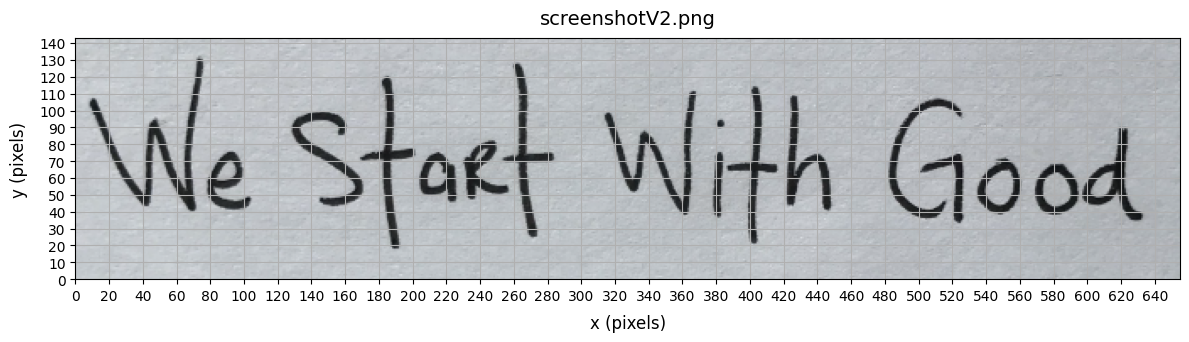

In [17]:
from matplotlib import pyplot as plt
import numpy as np

imagine = Image.open('screenshotV2.png').convert('RGB')
plt.figure(figsize=(12, 8))

w, h = imagine.size
plt.imshow(imagine, extent=(0, w, 0, h))

plt.title('screenshotV2.png', fontsize=14, pad=10)
plt.grid(True, alpha=1)

plt.xticks(np.arange(0, w, 20))   # every 50 pixels (adjust as needed)
plt.yticks(np.arange(0, h, 10))

plt.xlabel('x (pixels)', fontsize=12, labelpad=8)
plt.ylabel('y (pixels)', fontsize=12, labelpad=8)

plt.tight_layout()
plt.show()

In [18]:
true_boxes_SV2 = [
    # (letter, ((x_bot, y_bot) (x_top, y_top))
    ('w', 10, 40, 75, 130),
    ('e', 78, 40, 103, 75),
    ('S', 126, 43, 172, 100),
    ('t', 172, 19, 201, 120),
    ('a', 203, 45, 225, 75),
    ('r', 230, 46, 258, 82),
    ('t', 252, 25, 285, 129),
    ('W', 317, 39, 368, 112),
    ('i', 378, 39, 385, 95),
    ('t', 386, 20, 415, 115),
    ('h', 421, 41, 448, 110),
    ('G', 480, 33, 525, 108),
    ('o', 535, 39, 560, 72),
    ('o', 569, 38, 595, 70),
    ('d', 597, 35, 633, 90)
]

In [19]:
def tesseract_process_boxes(boxes: str):
    boxes_list = boxes.split('\n')[:-1]
    boxes_processed = []
    for line in boxes_list:
        letter, x_bot, y_bot, x_top, y_top, _ = line.split()
        boxes_processed.append((letter, int(x_bot), int(y_bot), int(x_top), int(y_top)))
    return boxes_processed

In [20]:
def overlap_aria_percentage(
        point_one: tuple[str, int, int, int, int],
        point_two: tuple[str, int, int, int, int]
):
    # (letter, ((x_bot, y_bot) (x_top, y_top))
    x_intersection_bot = max(point_one[1], point_two[1])
    y_intersection_bot = max(point_one[2], point_two[2])
    x_intersection_top = min(point_one[3], point_two[3])
    y_intersection_top = min(point_one[4], point_two[4])

    correct_area = (point_one[3] - point_one[1]) * (point_one[4] - point_one[2])
    intersection_area = (x_intersection_top - x_intersection_bot) * (y_intersection_top - y_intersection_bot)

    return intersection_area / correct_area

### Problems
1. We can't compare true_box_0 with pred_box_0, we need to do true_box_1 with pred_box_0 <br>
What if the ORC missed a box, but it got all the rest right? <br>
2. We can't just check the letters! <br>
What if it got the letter wrong but the box correct? <br><br>
**The solution, for each true box, find the pred box whose coordinates overlap the most (highest IoU), regardless of what letter it says.**

In [21]:
def compute_all_box_arias(true_boxes, pred_boxes):
    results = []
    used = set()  # track which pred boxes are already matched

    for true_box in true_boxes:
        best_score = 0.0
        best_idx = None

        for i, pred_box in enumerate(pred_boxes):
            if i in used:
                continue
            score = overlap_aria_percentage(true_box, pred_box)
            if score > best_score:
                best_score = score
                best_idx = i

        if best_idx is not None:
            used.add(best_idx)
            pred_char = pred_boxes[best_idx][0]
            char_correct = (pred_char == true_box[0])
            results.append({
                'char':          true_box[0],
                'pred_char':     pred_char,
                'char_correct':  char_correct,
                'overlap':       round(best_score, 4),
            })
        else:
            results.append({
                'char':         true_box[0],
                'pred_char':    None,
                'char_correct': False,
                'overlap':      0.0,
            })

    return results

In [22]:
def print_box_results(results: list):
    overlap_error = 0
    for result in results:
        print(f"For char {result['char']} : {result['pred_char']}, overlap {result['overlap']}")
        overlap_error += result['overlap']
    print(f"Overlap error: {1 - overlap_error/len(results)}")

In [23]:
boxes_SV2 = tesseract_process_boxes(
    pytesseract.image_to_boxes(Image.open('screenshotV2.png').convert('RGB'))
)
boxes_SV2_results = compute_all_box_arias(true_boxes_SV2, boxes_SV2)
print_box_results(boxes_SV2_results)

For char w : \, overlap 1.0
For char e : e, overlap 0.9714
For char S : S, overlap 0.897
For char t : t, overlap 1.0
For char a : a, overlap 0.9227
For char r : e, overlap 0.9375
For char t : t, overlap 0.8916
For char W : W, overlap 0.9863
For char i : i, overlap 0.9821
For char t : t, overlap 0.9789
For char h : h, overlap 0.949
For char G : G, overlap 0.9428
For char o : o, overlap 1.0
For char o : o, overlap 0.9375
For char d : d, overlap 1.0
Overlap error: 0.040213333333333434


### Improving text recognition

In [24]:
from PIL import ImageFilter, ImageEnhance

def preprocess_for_ocr(img, contrast_val: float = 2.0, threshold:bool = False, threshold_val:int = 144):
    img = img.convert("L")                                      # grayscale
    img = ImageEnhance.Contrast(img).enhance(contrast_val)      # contrast
    if threshold:
        img = img.point(lambda x: 0 if x < threshold_val else 255)  # black or white

    img = img.filter(ImageFilter.SHARPEN)

    return img

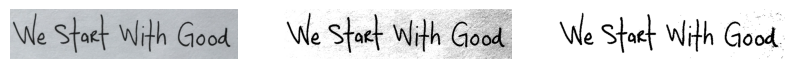

In [25]:
SV2_img = Image.open('ScreenshotV2.png')
SV2_img_better = preprocess_for_ocr(SV2_img, contrast_val=5.0)
SV2_img_better_v2 = preprocess_for_ocr(Image.open('ScreenshotV2.png'), contrast_val=5.0, threshold=True, threshold_val=144)

plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.imshow(SV2_img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(SV2_img_better, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(SV2_img_better_v2, cmap='gray')
plt.axis('off')
plt.show()

improved_report_SV2 = orc_and_eval_ImageFile(
    preprocess_for_ocr(
        Image.open('ScreenshotV2.png'),
        contrast_val=5.0
    ),
    'We Start With Good'
)

improved_report_SV2_v2 = orc_and_eval_ImageFile(
    preprocess_for_ocr(
        Image.open('ScreenshotV2.png'),
        contrast_val=5.0, threshold=True, threshold_val=144
    ),
    'We Start With Good'
)

In [26]:
print_results(report_SV2)

  Ground truth : 'We Start With Good'
  OCR output   : '\\Ne Staet With Good\n'
-------------------------------------------------------
  CHARACTER LEVEL
    Edit distance  : 3 characters
    Similarity     : 86.5%
    Error rate     : 15.8%  (CER)
  WORD LEVEL
    Edit distance  : 3 words
    Similarity     : 86.5%
    Error rate     : 75.0%  (WER)
  ADITIONAL
    Jaro Winkler distance: 91.0%
    Jaccard similarity: 76.9%


In [27]:
print_results(improved_report_SV2)

  Ground truth : 'We Start With Good'
  OCR output   : 'We Stack With Good\n'
-------------------------------------------------------
  CHARACTER LEVEL
    Edit distance  : 2 characters
    Similarity     : 88.9%
    Error rate     : 11.1%  (CER)
  WORD LEVEL
    Edit distance  : 2 words
    Similarity     : 88.9%
    Error rate     : 50.0%  (WER)
  ADITIONAL
    Jaro Winkler distance: 93.1%
    Jaccard similarity: 76.9%


In [28]:
print_results(improved_report_SV2_v2)

  Ground truth : 'We Start With Good'
  OCR output   : 'We Staet With Good,\n'
-------------------------------------------------------
  CHARACTER LEVEL
    Edit distance  : 2 characters
    Similarity     : 91.9%
    Error rate     : 10.5%  (CER)
  WORD LEVEL
    Edit distance  : 2 words
    Similarity     : 91.9%
    Error rate     : 50.0%  (WER)
  ADITIONAL
    Jaro Winkler distance: 96.8%
    Jaccard similarity: 83.3%


In this example... we can see a clear improvement! :D

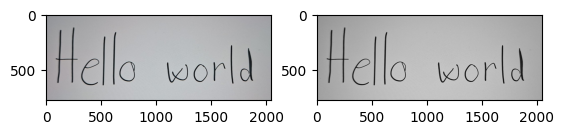

In [29]:
HW_img = Image.open('HELLO_WORD.jpeg')
HW_img_better = preprocess_for_ocr(Image.open('HELLO_WORD.jpeg'), contrast_val=1)

plt.subplot(1, 2, 1)
plt.imshow(HW_img)
plt.subplot(1, 2, 2)
plt.imshow(HW_img_better, cmap='gray')
plt.show()

improved_report_HW = orc_and_eval_ImageFile(
    preprocess_for_ocr(
        Image.open('HELLO_WORD.jpeg'),
        contrast_val=1
    ),
    'Hello world'
)

In [30]:
print_results(report_HW)

  Ground truth : 'Hello world'
  OCR output   : 'Hell world\n'
-------------------------------------------------------
  CHARACTER LEVEL
    Edit distance  : 1 characters
    Similarity     : 95.2%
    Error rate     : 10.0%  (CER)
  WORD LEVEL
    Edit distance  : 1 words
    Similarity     : 95.2%
    Error rate     : 50.0%  (WER)
  ADITIONAL
    Jaro Winkler distance: 96.2%
    Jaccard similarity: 100.0%


In [31]:
print_results(improved_report_HW)

  Ground truth : 'Hello world'
  OCR output   : ''
-------------------------------------------------------
  CHARACTER LEVEL
    Edit distance  : 11 characters
    Similarity     : 0.0%
    Error rate     : 1100.0%  (CER)
  WORD LEVEL
    Edit distance  : 11 words
    Similarity     : 0.0%
    Error rate     : 1100.0%  (WER)
  ADITIONAL
    Jaro Winkler distance: 0.0%
    Jaccard similarity: 0.0%
